---
date: "2026-08-31"
date-modified: last-modified
format:
  html:
    toc: true
---



# Gradient Descent and First-Order Optimization Algorithms

Training deep neural networks is formulated as an [optimization problem]() in high-dimensional parameter space $\mathbb{R}^P$. Because neural network loss surfaces are highly non-convex, exhibiting ill-conditioned ravines, saddle points, and stochastic mini-batch noise, first-order gradient methods serve as the workhorse of modern deep learning.

This note develops the mathematical foundations of first-order optimization, proves gradient descent convergence bounds under Lipschitz smoothness, establishes the variance properties of Stochastic Gradient Descent (SGD), analyzes momentum dynamics, and derives the exact bias-corrected moment estimates of the **Adam** optimizer.

---

## 1\. Empirical Risk Minimization & Gradient Descent Foundations

Let $\mathcal{D} = \{(\mathbf{x}_i, \mathbf{y}_i)\}_{i=1}^I$ denote a training dataset of $I$ independent and identically distributed samples. Let $\boldsymbol{\phi} \in \mathbb{R}^P$ denote the vector of network parameters. The training objective is to minimize the **empirical risk** (average loss):

$$
\min_{\boldsymbol{\phi} \in \mathbb{R}^P} L[\boldsymbol{\phi}] = \frac{1}{I} \sum_{i=1}^I \ell_i[\boldsymbol{\phi}] \equiv \frac{1}{I} \sum_{i=1}^I \ell(\mathbf{f}[\mathbf{x}_i, \boldsymbol{\phi}], \mathbf{y}_i)
$$

::: {#def-gradient-descent}
## Full Batch Gradient Descent
Let $\nabla_{\boldsymbol{\phi}} L[\boldsymbol{\phi}] \in \mathbb{R}^P$ denote the [gradient]() vector of the loss function. Full Batch Gradient Descent updates the parameters iteratively according to:

$$
\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \alpha \nabla_{\boldsymbol{\phi}} L[\boldsymbol{\phi}_t]
$$

where $\alpha > 0$ is the **learning rate** (step size).
:::

### 1.1\. Descent Lemma & Step Size Bounds

::: {#thm-descent-lemma}
## Guaranteed Descent Under $L_{\text{smooth}}$-Lipschitz Continuous Gradients
Suppose the loss function $L[\boldsymbol{\phi}]$ is continuously differentiable and its gradient is $L_{\text{smooth}}$-Lipschitz continuous, i.e., for all $\boldsymbol{\phi}_1, \boldsymbol{\phi}_2 \in \mathbb{R}^P$:

$$
\|\nabla L[\boldsymbol{\phi}_1] - \nabla L[\boldsymbol{\phi}_2]\|_2 \le L_{\text{smooth}} \|\boldsymbol{\phi}_1 - \boldsymbol{\phi}_2\|_2
$$

If the learning rate satisfies $0 < \alpha < \frac{2}{L_{\text{smooth}}}$, the gradient descent update guarantees a decrease in the objective function at each iteration:

$$
L[\boldsymbol{\phi}_{t+1}] \le L[\boldsymbol{\phi}_t] - \alpha \left( 1 - \frac{\alpha L_{\text{smooth}}}{2} \right) \|\nabla L[\boldsymbol{\phi}_t]\|_2^2
$$

In particular, choosing $\alpha = \frac{1}{L_{\text{smooth}}}$ maximizes the guaranteed per-step decrease:

$$
L[\boldsymbol{\phi}_{t+1}] \le L[\boldsymbol{\phi}_t] - \frac{1}{2 L_{\text{smooth}}} \|\nabla L[\boldsymbol{\phi}_t]\|_2^2
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Descent Lemma
By the multivariate Taylor theorem with integral remainder:
$$
L[\boldsymbol{\phi}_{t+1}] = L[\boldsymbol{\phi}_t] + \langle \nabla L[\boldsymbol{\phi}_t], \boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t \rangle + \int_0^1 \langle \nabla L[\boldsymbol{\phi}_t + \tau(\boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t)] - \nabla L[\boldsymbol{\phi}_t], \boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t \rangle d\tau
$$
Applying the Cauchy-Schwarz inequality and $L_{\text{smooth}}$-Lipschitz continuity of the gradient:
$$
\begin{aligned}
L[\boldsymbol{\phi}_{t+1}] &\le L[\boldsymbol{\phi}_t] + \langle \nabla L[\boldsymbol{\phi}_t], \boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t \rangle + \int_0^1 L_{\text{smooth}} \tau \|\boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t\|_2^2 d\tau \\
&= L[\boldsymbol{\phi}_t] + \langle \nabla L[\boldsymbol{\phi}_t], \boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t \rangle + \frac{L_{\text{smooth}}}{2} \|\boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t\|_2^2
\end{aligned}
$$
Substituting the gradient descent update $\boldsymbol{\phi}_{t+1} - \boldsymbol{\phi}_t = -\alpha \nabla L[\boldsymbol{\phi}_t]$:
$$
\begin{aligned}
L[\boldsymbol{\phi}_{t+1}] &\le L[\boldsymbol{\phi}_t] - \alpha \|\nabla L[\boldsymbol{\phi}_t]\|_2^2 + \frac{\alpha^2 L_{\text{smooth}}}{2} \|\nabla L[\boldsymbol{\phi}_t]\|_2^2 \\
&= L[\boldsymbol{\phi}_t] - \alpha \left( 1 - \frac{\alpha L_{\text{smooth}}}{2} \right) \|\nabla L[\boldsymbol{\phi}_t]\|_2^2
\end{aligned}
$$
For $\alpha \in (0, 2/L_{\text{smooth}})$, the coefficient $\alpha(1 - \alpha L_{\text{smooth}}/2) > 0$, ensuring $L[\boldsymbol{\phi}_{t+1}] < L[\boldsymbol{\phi}_t]$ whenever $\nabla L[\boldsymbol{\phi}_t] \neq \mathbf{0}$. $\blacksquare$
:::



## 2\. Stochastic Gradient Descent (SGD) and Mini-Batching

Computing the full batch gradient requires evaluating $\nabla \ell_i[\boldsymbol{\phi}]$ across all $I$ training samples, which is computationally prohibitive when $I \gg 10^6$. Mini-batch **Stochastic Gradient Descent (SGD)** approximates the true gradient using a random subset of samples.

::: {#def-sgd}
## Mini-Batch Stochastic Gradient Descent
Let $\mathcal{B}_t \subset \{1, 2, \dots, I\}$ be a mini-batch of $B = |\mathcal{B}_t|$ indices [sampled without replacement](sampling-without-replacement.ipynb) from the training set. The stochastic mini-batch gradient $\mathbf{g}_t$ is defined as:

$$
\mathbf{g}_t \equiv \nabla_{\boldsymbol{\phi}} L_B[\boldsymbol{\phi}_t] = \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla_{\boldsymbol{\phi}} \ell_i[\boldsymbol{\phi}_t]
$$

The parameter update rule is:

$$
\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \alpha \mathbf{g}_t
$$
:::

### 2.1\. Unbiasedness and Variance Scaling of Mini-Batch Gradients

::: {#prp-sgd-variance}
## Statistical Properties of Stochastic Mini-Batch Gradients
Let $\mathbf{g}_t$ be the mini-batch gradient sampled uniformly at random. Then:

1. **Unbiased Estimator:** The [expected value](expectation.ipynb) of $\mathbf{g}_t$ is equal to the true full batch gradient:
   $$
   \mathbb{E}_{\mathcal{B}_t}[\mathbf{g}_t] = \nabla L[\boldsymbol{\phi}_t]
   $$
2. **Variance Scaling:** The [variance](variance.ipynb) of $\mathbf{g}_t$ scales inversely with the mini-batch size $B$:
   $$
   \text{Cov}(\mathbf{g}_t) = \frac{I - B}{I - 1} \frac{\boldsymbol{\Sigma}^2(\boldsymbol{\phi}_t)}{B} \approx \frac{\boldsymbol{\Sigma}^2(\boldsymbol{\phi}_t)}{B}
   $$
   where $\boldsymbol{\Sigma}^2(\boldsymbol{\phi}_t) = \frac{1}{I} \sum_{i=1}^I (\nabla \ell_i[\boldsymbol{\phi}_t] - \nabla L[\boldsymbol{\phi}_t])(\nabla \ell_i[\boldsymbol{\phi}_t] - \nabla L[\boldsymbol{\phi}_t])^T$.
:::

::: {.callout-tip collapse="true"}
## Proof of Proposition: SGD Gradient Statistics
Let $I_i \in \{0, 1\}$ be the indicator that sample $i$ is selected into batch $\mathcal{B}_t$. Since each of the $\binom{I}{B}$ subsets is equally likely, $P(I_i = 1) = \frac{B}{I}$, and for $i \neq j$, $P(I_i = 1, I_j = 1) = \frac{B(B-1)}{I(I-1)}$.

1. **Expectation:**
   $$
   \mathbb{E}[\mathbf{g}_t] = \mathbb{E}\left[ \frac{1}{B} \sum_{i=1}^I I_i \nabla \ell_i[\boldsymbol{\phi}_t] \right] = \frac{1}{B} \sum_{i=1}^I \mathbb{E}[I_i] \nabla \ell_i[\boldsymbol{\phi}_t] = \frac{1}{B} \sum_{i=1}^I \frac{B}{I} \nabla \ell_i[\boldsymbol{\phi}_t] = \frac{1}{I} \sum_{i=1}^I \nabla \ell_i[\boldsymbol{\phi}_t] = \nabla L[\boldsymbol{\phi}_t]
   $$
2. **Covariance:**
   Using the standard finite-population sampling variance formula:
   $$
   \text{Cov}\left( \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla \ell_i \right) = \frac{I - B}{I - 1} \frac{\boldsymbol{\Sigma}^2}{B}
   $$
   For large datasets $I \gg B$, the finite population correction factor $\frac{I-B}{I-1} \approx 1$, giving $\text{Cov}(\mathbf{g}_t) \approx \frac{\boldsymbol{\Sigma}^2}{B}$. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Stochastic Noise as Implicit Regularization
The stochastic fluctuation $\boldsymbol{\xi}_t = \mathbf{g}_t - \nabla L[\boldsymbol{\phi}_t]$ acts as anisotropic Gaussian-like diffusion on the loss landscape. This prevents optimization from becoming trapped in shallow, sharp local minima and drives parameters toward flatter, broader basins that generalize substantially better to test data.
:::



## 3\. Momentum and Nesterov Accelerated Gradient

Standard SGD struggles in ravines where the surface curves much more steeply in one dimension than in another, leading to high-frequency transverse oscillations.

::: {#def-momentum}
## Polyak Classical Momentum (Heavy Ball Method)
Momentum introduces a velocity vector $\mathbf{m}_t \in \mathbb{R}^P$ that accumulates an exponential moving average of past gradients:

$$
\begin{aligned}
\mathbf{m}_t &= \beta \mathbf{m}_{t-1} + (1 - \beta) \mathbf{g}_t \\
\boldsymbol{\phi}_{t+1} &= \boldsymbol{\phi}_t - \alpha \mathbf{m}_t
\end{aligned}
$$

where $\beta \in [0, 1)$ is the momentum decay factor (typically $\beta = 0.9$).
:::

In continuous time, this corresponds to the second-order Newtonian equation of motion of a heavy particle rolling down a potential well $L(\boldsymbol{\phi})$ with friction:

$$
m \frac{d^2 \boldsymbol{\phi}(t)}{dt^2} + \gamma \frac{d\boldsymbol{\phi}(t)}{dt} = -\nabla L(\boldsymbol{\phi}(t))
$$

### 3.1\. Nesterov Accelerated Gradient (NAG)

Nesterov momentum evaluates the gradient not at the current position $\boldsymbol{\phi}_t$, but at the "look-ahead" anticipated position $\boldsymbol{\phi}_t - \alpha \beta \mathbf{m}_{t-1}$:

$$
\begin{aligned}
\mathbf{m}_t &= \beta \mathbf{m}_{t-1} + (1 - \beta) \nabla L_B\left[ \boldsymbol{\phi}_t - \alpha \beta \mathbf{m}_{t-1} \right] \\
\boldsymbol{\phi}_{t+1} &= \boldsymbol{\phi}_t - \alpha \mathbf{m}_t
\end{aligned}
$$

This forward look-ahead acts as an adaptive predictive brake, significantly reducing overshooting when descending steep valleys.

---

## 4\. Adaptive Learning Rate Algorithms: AdaGrad, RMSprop, and Adam

Different parameters may require distinct step sizes: infrequent features need larger updates, while dense features require cautious steps.

### 4.1\. AdaGrad and RMSprop

* **AdaGrad (Duchi et al., 2011):** Accumulates sum of squared gradients $\mathbf{v}_t = \mathbf{v}_{t-1} + \mathbf{g}_t \odot \mathbf{g}_t$. The update $\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \frac{\alpha}{\sqrt{\mathbf{v}_t} + \varepsilon} \odot \mathbf{g}_t$ causes monotonic decay of effective step sizes to zero prematurely.
* **RMSprop (Hinton, 2012):** Replaces the monotonically increasing sum with an exponentially decaying average:
  $$
  \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t \odot \mathbf{g}_t
  $$

### 4.2\. Adam (Adaptive Moment Estimation)

::: {#def-adam}
## Adam Optimizer (Kingma & Ba, 2014)
Adam combines first-order momentum (first moment $\mathbf{m}_t$) with RMSprop (uncentered second moment $\mathbf{v}_t$), incorporating analytical bias corrections:

$$
\begin{aligned}
\mathbf{m}_t &= \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t \quad &&\text{(Biased 1st Moment)} \\
\mathbf{v}_t &= \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t \odot \mathbf{g}_t \quad &&\text{(Biased 2nd Moment)} \\
\hat{\mathbf{m}}_t &= \frac{\mathbf{m}_t}{1 - \beta_1^t} \quad &&\text{(Bias-Corrected 1st Moment)} \\
\hat{\mathbf{v}}_t &= \frac{\mathbf{v}_t}{1 - \beta_2^t} \quad &&\text{(Bias-Corrected 2nd Moment)} \\
\boldsymbol{\phi}_{t+1} &= \boldsymbol{\phi}_t - \frac{\alpha}{\sqrt{\hat{\mathbf{v}}_t} + \varepsilon} \odot \hat{\mathbf{m}}_t \quad &&\text{(Parameter Update)}
\end{aligned}
$$

Standard default hyperparameters: $\alpha = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$.
:::

::: {#thm-adam-bias-correction}
## Derivation of Adam Moment Bias Corrections
Assuming moments are initialized at zero ($\mathbf{m}_0 = \mathbf{0}, \mathbf{v}_0 = \mathbf{0}$) and the true gradient distribution has approximately stationary first and second moments $\mathbb{E}[\mathbf{g}_i] \approx \mathbb{E}[\mathbf{g}_t]$ and $\mathbb{E}[\mathbf{g}_i^2] \approx \mathbb{E}[\mathbf{g}_t^2]$, the uncorrected moments $\mathbf{m}_t$ and $\mathbf{v}_t$ are biased toward zero with:

$$
\mathbb{E}[\mathbf{m}_t] = (1 - \beta_1^t) \mathbb{E}[\mathbf{g}_t] \quad \text{and} \quad \mathbb{E}[\mathbf{v}_t] = (1 - \beta_2^t) \mathbb{E}[\mathbf{g}_t^2]
$$

Dividing by $1 - \beta_1^t$ and $1 - \beta_2^t$ produces strictly unbiased estimators $\mathbb{E}[\hat{\mathbf{m}}_t] = \mathbb{E}[\mathbf{g}_t]$ and $\mathbb{E}[\hat{\mathbf{v}}_t] = \mathbb{E}[\mathbf{g}_t^2]$.
:::

::: {.callout-tip collapse="true"}
## Proof of Adam Bias Correction
Unrolling the first moment recurrence relation $\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t$ with $\mathbf{m}_0 = \mathbf{0}$:
$$
\begin{aligned}
\mathbf{m}_t &= (1 - \beta_1) \mathbf{g}_t + \beta_1 (1 - \beta_1) \mathbf{g}_{t-1} + \beta_1^2 (1 - \beta_1) \mathbf{g}_{t-2} + \dots + \beta_1^{t-1}(1 - \beta_1)\mathbf{g}_1 \\
&= (1 - \beta_1) \sum_{i=1}^t \beta_1^{t-i} \mathbf{g}_i
\end{aligned}
$$
Taking the expectation on both sides:
$$
\mathbb{E}[\mathbf{m}_t] = (1 - \beta_1) \sum_{i=1}^t \beta_1^{t-i} \mathbb{E}[\mathbf{g}_i]
$$
Under the assumption of stationary expectation $\mathbb{E}[\mathbf{g}_i] = \mathbb{E}[\mathbf{g}_t]$:
$$
\mathbb{E}[\mathbf{m}_t] = \mathbb{E}[\mathbf{g}_t] (1 - \beta_1) \sum_{i=1}^t \beta_1^{t-i} = \mathbb{E}[\mathbf{g}_t] (1 - \beta_1) \frac{1 - \beta_1^t}{1 - \beta_1} = (1 - \beta_1^t) \mathbb{E}[\mathbf{g}_t]
$$
Therefore, defining $\hat{\mathbf{m}}_t \equiv \frac{\mathbf{m}_t}{1 - \beta_1^t}$ yields:
$$
\mathbb{E}[\hat{\mathbf{m}}_t] = \frac{\mathbb{E}[\mathbf{m}_t]}{1 - \beta_1^t} = \mathbb{E}[\mathbf{g}_t]
$$
The identical derivation applies directly to $\mathbf{v}_t$ replacing $\beta_1$ with $\beta_2$ and $\mathbf{g}_i$ with $\mathbf{g}_i^2$. $\blacksquare$
:::



## 5\. Comparative Summary of First-Order Optimization Algorithms

| Algorithm | First Moment ($\mathbf{m}_t$) | Second Moment ($\mathbf{v}_t$) | Parameter Update Step | Memory Overhead |
| :--- | :--- | :--- | :--- | :--- |
| **SGD** | $\mathbf{g}_t$ | None | $\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \alpha \mathbf{g}_t$ | $\mathcal{O}(0)$ |
| **Momentum** | $\beta \mathbf{m}_{t-1} + (1-\beta)\mathbf{g}_t$ | None | $\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \alpha \mathbf{m}_t$ | $\mathcal{O}(P)$ |
| **AdaGrad** | $\mathbf{g}_t$ | $\mathbf{v}_{t-1} + \mathbf{g}_t^2$ | $\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \frac{\alpha}{\sqrt{\mathbf{v}_t} + \varepsilon} \odot \mathbf{g}_t$ | $\mathcal{O}(P)$ |
| **RMSprop** | $\mathbf{g}_t$ | $\beta \mathbf{v}_{t-1} + (1-\beta)\mathbf{g}_t^2$ | $\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \frac{\alpha}{\sqrt{\mathbf{v}_t} + \varepsilon} \odot \mathbf{g}_t$ | $\mathcal{O}(P)$ |
| **Adam** | $\frac{\beta_1 \mathbf{m}_{t-1} + (1-\beta_1)\mathbf{g}_t}{1 - \beta_1^t}$ | $\frac{\beta_2 \mathbf{v}_{t-1} + (1-\beta_2)\mathbf{g}_t^2}{1 - \beta_2^t}$ | $\boldsymbol{\phi}_{t+1} = \boldsymbol{\phi}_t - \frac{\alpha}{\sqrt{\hat{\mathbf{v}}_t} + \varepsilon} \odot \hat{\mathbf{m}}_t$ | $\mathcal{O}(2P)$ |



## 6\. PyTorch Implementation & Optimization Dynamics Simulation

We simulate and visualize optimization paths across an ill-conditioned 2D non-convex loss surface (an anisotropic Rosenbrock-like valley) comparing:
1. Standard Gradient Descent (oscillates across ravines)
2. SGD with Stochastic Noise
3. Momentum (smooths oscillations and accelerates down the valley)
4. RMSprop (scales updates along ill-conditioned axes)
5. Adam (combines momentum acceleration with adaptive scaling)


Running optimizer simulation on: cuda


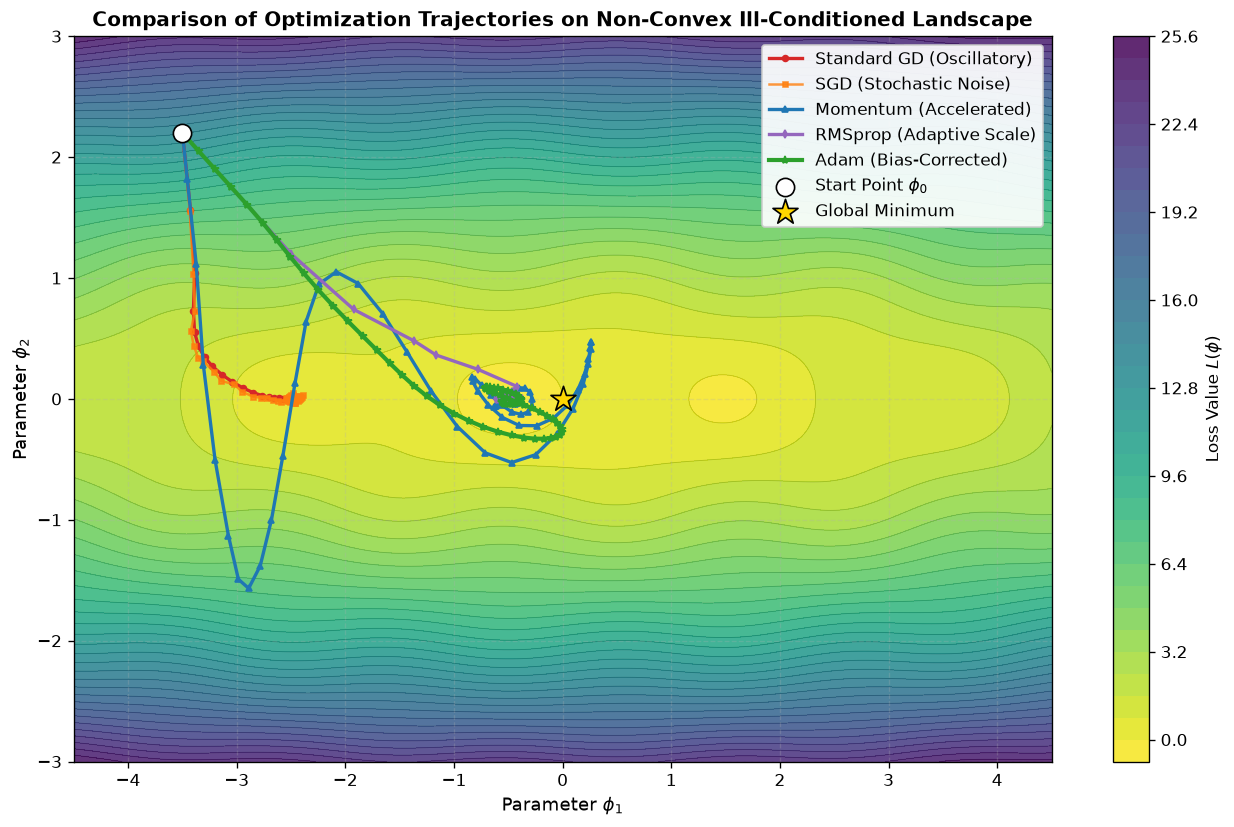

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running optimizer simulation on: {device}")

# Define an ill-conditioned 2D non-convex potential: f(x, y) = 0.1*x^2 + 2.5*y^2 + 0.4*sin(3*x)*cos(3*y)
def loss_fn(p):
    x, y = p[0], p[1]
    return 0.1 * x**2 + 2.5 * y**2 + 0.4 * torch.sin(3.0 * x) * torch.cos(3.0 * y)

# Function to run an optimizer trajectory
def run_trajectory(opt_name, lr=0.08, steps=80, noise_std=0.0):
    torch.manual_seed(42)
    p = torch.tensor([-3.5, 2.2], dtype=torch.float32, requires_grad=True)
    
    if opt_name == "GD":
        optimizer = torch.optim.SGD([p], lr=lr, momentum=0.0)
    elif opt_name == "SGD (Noisy)":
        optimizer = torch.optim.SGD([p], lr=lr, momentum=0.0)
    elif opt_name == "Momentum":
        optimizer = torch.optim.SGD([p], lr=lr*0.6, momentum=0.9)
    elif opt_name == "RMSprop":
        optimizer = torch.optim.RMSprop([p], lr=lr, alpha=0.99)
    elif opt_name == "Adam":
        optimizer = torch.optim.Adam([p], lr=lr, betas=(0.9, 0.999))
    else:
        raise ValueError(f"Unknown optimizer {opt_name}")
        
    path = [p.detach().clone().numpy()]
    
    for step in range(steps):
        optimizer.zero_grad()
        loss = loss_fn(p)
        loss.backward()
        if noise_std > 0:
            with torch.no_grad():
                p.grad += torch.randn_like(p.grad) * noise_std
        optimizer.step()
        path.append(p.detach().clone().numpy())
        
    return np.array(path)

# Run simulations
traj_gd = run_trajectory("GD", lr=0.06, steps=70)
traj_sgd = run_trajectory("SGD (Noisy)", lr=0.06, steps=70, noise_std=0.35)
traj_mom = run_trajectory("Momentum", lr=0.06, steps=70)
traj_rms = run_trajectory("RMSprop", lr=0.10, steps=70)
traj_adam = run_trajectory("Adam", lr=0.15, steps=70)

# Create 2D contour plot
x_grid = np.linspace(-4.5, 4.5, 400)
y_grid = np.linspace(-3.0, 3.0, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z = 0.1 * X**2 + 2.5 * Y**2 + 0.4 * np.sin(3.0 * X) * np.cos(3.0 * Y)

plt.figure(figsize=(11, 7), dpi=120)
cp = plt.contourf(X, Y, Z, levels=35, cmap='viridis_r', alpha=0.85)
plt.colorbar(cp, label=r'Loss Value $L(\phi)$')
plt.contour(X, Y, Z, levels=35, colors='k', alpha=0.15, linewidths=0.5)

plt.plot(traj_gd[:, 0], traj_gd[:, 1], 'o-', label='Standard GD (Oscillatory)', color='#d62728', lw=2, markersize=3.5)
plt.plot(traj_sgd[:, 0], traj_sgd[:, 1], 's-', label='SGD (Stochastic Noise)', color='#ff7f0e', lw=1.5, markersize=3, alpha=0.8)
plt.plot(traj_mom[:, 0], traj_mom[:, 1], '^-', label='Momentum (Accelerated)', color='#1f77b4', lw=2, markersize=3.5)
plt.plot(traj_rms[:, 0], traj_rms[:, 1], 'd-', label='RMSprop (Adaptive Scale)', color='#9467bd', lw=2, markersize=3.5)
plt.plot(traj_adam[:, 0], traj_adam[:, 1], '*-', label='Adam (Bias-Corrected)', color='#2ca02c', lw=2.5, markersize=5)

plt.scatter([-3.5], [2.2], color='white', edgecolor='black', s=120, zorder=10, label=r'Start Point $\phi_0$')
plt.scatter([0.0], [0.0], color='gold', edgecolor='black', marker='*', s=250, zorder=10, label='Global Minimum')

plt.title('Comparison of Optimization Trajectories on Non-Convex Ill-Conditioned Landscape', fontsize=12, fontweight='bold')
plt.xlabel(r'Parameter $\phi_1$', fontsize=11)
plt.ylabel(r'Parameter $\phi_2$', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.92, loc='upper right')
plt.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()


---

> **References & Acknowledgments:**
>
> * Prince, Simon J.D. *Understanding Deep Learning*, MIT Press, 2023. Chapter 6.
> * Kingma, Diederik P., and Jimmy Ba. "Adam: A method for stochastic optimization." *International Conference on Learning Representations (ICLR)*, 2015.
> * Polyak, Boris T. "Some methods of speeding up the convergence of iteration methods." *USSR Computational Mathematics and Mathematical Physics* 4.5 (1964): 1-17.
> * Duchi, John, Elad Hazan, and Yoram Singer. "Adaptive subgradient methods for online learning and stochastic optimization." *Journal of Machine Learning Research* 12 (2011): 2121-2159.
